# Ein 3-schichtiges Feedforward-Netz

**Ziel:** Implementiere genau das Netz aus dem Diagramm — 2 Eingaben, zwei versteckte Schichten mit je 4 Neuronen und 1 Ausgabeneuron — zuerst Neuron für Neuron (exakt nach der Notation), dann vektorisiert, und schließlich trainiert auf einem 2D-Spielzeugdatensatz.

Notation (aus *The Hundred-Page Machine Learning Book*):

- Schicht 1 ($f_1$): $y_1^{(j)} \leftarrow g_1(\mathbf{w}_{1,j}\mathbf{x} + b_{1,j})$ für $j = 1..4$
- Schicht 2 ($f_2$): $y_2^{(j)} \leftarrow g_2(\mathbf{w}_{2,j}\mathbf{y}_1 + b_{2,j})$ für $j = 1..4$
- Schicht 3 ($f_3$): $y \leftarrow g_3(\mathbf{w}_{3,1}\mathbf{y}_2 + b_{3,1})$

Jedes $g_i$ ist eine Aktivierungsfunktion (wir verwenden überall die Sigmoid-Funktion, da wir einen binären Klassifikator bauen).

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

---
## Teil 1 — Aktivierungsfunktion

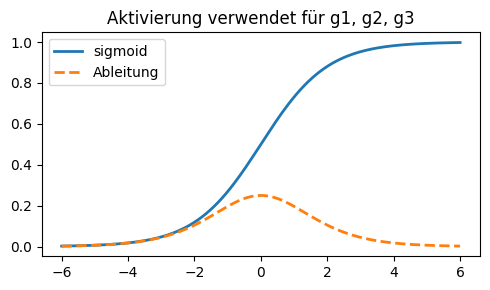

In [ ]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def sigmoid_deriv(z):
    s = sigmoid(z)
    return s * (1 - s)

z = np.linspace(-6, 6, 200)
plt.figure(figsize=(5, 3))
plt.plot(z, sigmoid(z), lw=2, label="sigmoid")
plt.plot(z, sigmoid_deriv(z), lw=2, linestyle="--", label="Ableitung")
plt.legend()
plt.title("Aktivierung verwendet für g1, g2, g3")
plt.tight_layout()
plt.show()

---
## Teil 2 — Spielzeugdatensatz (2 Eingaben, passend zu $x^{(1)}, x^{(2)}$)

XOR benötigt nur eine einzige versteckte Schicht zur Lösung. Damit die *zweite* versteckte Schicht wirklich gebraucht wird, verwenden wir ein schwierigeres 2D-Problem: zwei konzentrische Kreise. Das ist nicht linear trennbar und profitiert von zusätzlicher Tiefe.

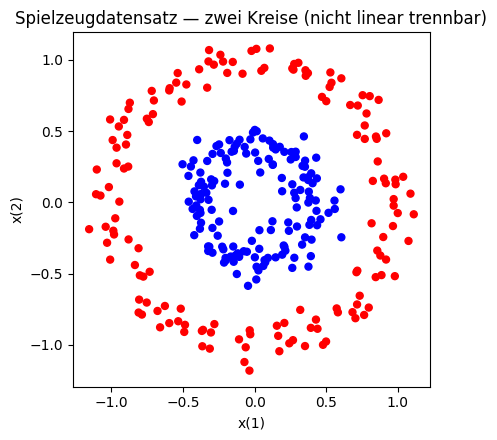

In [ ]:
from sklearn.datasets import make_circles

X, y = make_circles(n_samples=300, noise=0.08, factor=0.4, random_state=42)
y = y.reshape(-1, 1).astype(float)

plt.figure(figsize=(4.5, 4.5))
colors = ["red" if yi == 0 else "blue" for yi in y.flatten()]
plt.scatter(X[:, 0], X[:, 1], c=colors, s=25, zorder=3)
plt.xlabel("x(1)")
plt.ylabel("x(2)")
plt.title("Spielzeugdatensatz — zwei Kreise (nicht linear trennbar)")
plt.tight_layout()
plt.show()

---
## Teil 3 — Vorwärtsdurchlauf Neuron für Neuron (entspricht exakt dem Diagramm)

Bevor wir vektorisieren, berechnen wir einen einzelnen Vorwärtsdurchlauf genau so, wie das Diagramm ihn notiert: ein Gewichtsvektor $\mathbf{w}_{i,j}$ und ein Bias $b_{i,j}$ pro Neuron $j$ in Schicht $i$.

In [ ]:
# Zufällige Gewichte/Biases für ein Beispiel, nur um die Gleichungen des Diagramms zu zeigen
x = X[0]  # ein einzelnes Beispiel: [x(1), x(2)]

# Schicht 1: 4 Neuronen, jedes betrachtet die 2 Eingaben
W1 = [np.random.randn(2) * 0.5 for _ in range(4)]
b1 = [0.0 for _ in range(4)]

y1 = np.array([sigmoid(W1[j] @ x + b1[j]) for j in range(4)])
print("y1 (Ausgabe Schicht 1, 4 Werte):", y1)

# Schicht 2: 4 Neuronen, jedes betrachtet die 4 Ausgaben von Schicht 1
W2 = [np.random.randn(4) * 0.5 for _ in range(4)]
b2 = [0.0 for _ in range(4)]

y2 = np.array([sigmoid(W2[j] @ y1 + b2[j]) for j in range(4)])
print("y2 (Ausgabe Schicht 2, 4 Werte):", y2)

# Schicht 3: 1 Neuron, betrachtet die 4 Ausgaben von Schicht 2
W3 = np.random.randn(4) * 0.5
b3 = 0.0

y_out = sigmoid(W3 @ y2 + b3)
print("y (finale Ausgabe):", y_out)

y1 (Ausgabe Schicht 1, 4 Werte): [0.48474587 0.55685668 0.49366256 0.50605161]
y2 (Ausgabe Schicht 2, 4 Werte): [0.45141592 0.26074437 0.32312103 0.48713811]
y (finale Ausgabe): 0.44945894923569235


Das ist genau $f_3(f_2(f_1(\mathbf{x})))$ — drei Funktionsverkettungen, eine pro Schicht. Über Neuronen einzeln zu iterieren ist anschaulich, aber langsam. Als Nächstes vektorisieren wir das: die Gewichtsvektoren $\mathbf{w}_{i,1}, ..., \mathbf{w}_{i,4}$ jeder Schicht werden zu Zeilen einer einzigen Gewichtsmatrix $W_i$, sodass eine ganze Schicht eine einzige Matrixmultiplikation ist.

---
## Teil 4 — Vektorisiertes 3-Schichten-Netz mit Backpropagation

In [ ]:
class ThreeLayerNet:
    def __init__(self, n_input, n_hidden1, n_hidden2, n_output):
        # Xavier-Initialisierung: hält die Varianz über die Schichten hinweg stabil
        self.W1 = np.random.randn(n_input, n_hidden1) * np.sqrt(2 / n_input)
        self.b1 = np.zeros((1, n_hidden1))
        self.W2 = np.random.randn(n_hidden1, n_hidden2) * np.sqrt(2 / n_hidden1)
        self.b2 = np.zeros((1, n_hidden2))
        self.W3 = np.random.randn(n_hidden2, n_output) * np.sqrt(2 / n_hidden2)
        self.b3 = np.zeros((1, n_output))

    def forward(self, X):
        self.X  = X
        self.z1 = X @ self.W1 + self.b1
        self.y1 = sigmoid(self.z1)          # Ausgabe Schicht 1
        self.z2 = self.y1 @ self.W2 + self.b2
        self.y2 = sigmoid(self.z2)          # Ausgabe Schicht 2
        self.z3 = self.y2 @ self.W3 + self.b3
        self.y  = sigmoid(self.z3)          # Ausgabe Schicht 3 (finale Vorhersage)
        return self.y

    def loss(self, y_pred, y_true):
        eps = 1e-8  # verhindert log(0)
        return -np.mean(y_true * np.log(y_pred + eps) + (1 - y_true) * np.log(1 - y_pred + eps))

    def backward(self, y_true, lr):
        n = y_true.shape[0]

        # Gradienten Schicht 3
        dz3 = (self.y - y_true) * sigmoid_deriv(self.z3)
        dW3 = self.y2.T @ dz3 / n
        db3 = np.sum(dz3, axis=0, keepdims=True) / n

        # Gradienten Schicht 2
        dy2 = dz3 @ self.W3.T
        dz2 = dy2 * sigmoid_deriv(self.z2)
        dW2 = self.y1.T @ dz2 / n
        db2 = np.sum(dz2, axis=0, keepdims=True) / n

        # Gradienten Schicht 1
        dy1 = dz2 @ self.W2.T
        dz1 = dy1 * sigmoid_deriv(self.z1)
        dW1 = self.X.T @ dz1 / n
        db1 = np.sum(dz1, axis=0, keepdims=True) / n

        # Gradientenabstieg-Update
        self.W3 -= lr * dW3
        self.b3 -= lr * db3
        self.W2 -= lr * dW2
        self.b2 -= lr * db2
        self.W1 -= lr * dW1
        self.b1 -= lr * db1

print("ThreeLayerNet definiert")

ThreeLayerNet definiert


---
## Teil 5 — Training auf dem Zwei-Kreise-Datensatz

In [ ]:
net = ThreeLayerNet(n_input=2, n_hidden1=4, n_hidden2=4, n_output=1)
lr     = 1.0
epochs = 8000
history = []

for epoch in range(epochs):
    y_pred = net.forward(X)
    loss   = net.loss(y_pred, y)
    #print("epoch: ", epoch, ", loss: ", loss)
    history.append(loss)
    net.backward(y, lr)

pred_labels = (net.forward(X) > 0.5).astype(int)
accuracy = np.mean(pred_labels == y)
print(f"Finaler Loss: {history[-1]:.4f}")
print(f"Finale Genauigkeit: {accuracy:.2%}")

Finaler Loss: 0.0246
Finale Genauigkeit: 100.00%


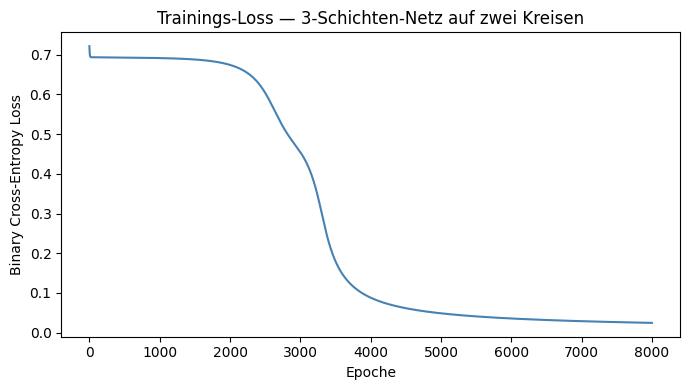

In [ ]:
plt.figure(figsize=(7, 4))
plt.plot(history, color="steelblue")
plt.xlabel("Epoche")
plt.ylabel("Binary Cross-Entropy Loss")
plt.title("Trainings-Loss — 3-Schichten-Netz auf zwei Kreisen")
plt.tight_layout()
plt.show()

---
## Teil 6 — Entscheidungsgrenze visualisieren

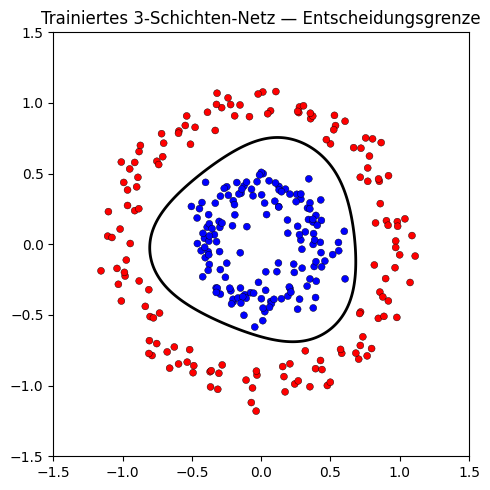

In [ ]:
def plot_boundary(net, title):
    xx, yy = np.meshgrid(np.linspace(-1.5, 1.5, 300),
                         np.linspace(-1.5, 1.5, 300))
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = net.forward(grid).reshape(xx.shape)

    plt.figure(figsize=(5, 5))
    plt.contour(xx, yy, Z, levels=[0.5], colors="black", linewidths=2)
    colors = ["red" if yi == 0 else "blue" for yi in y.flatten()]
    plt.scatter(X[:, 0], X[:, 1], c=colors, s=25, zorder=3, edgecolors="k", linewidths=0.3)
    plt.title(title)
    plt.tight_layout()
    plt.show()

plot_boundary(net, "Trainiertes 3-Schichten-Netz — Entscheidungsgrenze")

---
## Übungen

1. Entferne Schicht 2 komplett (zurück zu einer einzigen versteckten Schicht wie in Lesson 3). Kann ein 2-Schichten-Netz das Zwei-Kreise-Problem genauso gut lösen?
2. Ändere `n_hidden1` und `n_hidden2` von 4 auf 2. Konvergiert das Netz noch?
3. Tausche `sigmoid` in den versteckten Schichten gegen `relu` aus (behalte `sigmoid` in der Ausgabeschicht für Wahrscheinlichkeiten bei). Ändert sich Trainingsgeschwindigkeit oder Stabilität?
4. Probiere `make_moons` statt `make_circles` aus (beide aus `sklearn.datasets`). Löst dieselbe Architektur auch dieses Problem?

---
## Zusammenfassung

- Die Neuron-für-Neuron-Gleichungen des Diagramms $y_i^{(j)} \leftarrow g_i(\mathbf{w}_{i,j}\mathbf{y}_{i-1} + b_{i,j})$ sind nur eine Zeile einer Matrixmultiplikation — das Stapeln von Neuronen macht aus der Schleife `X @ W + b`.
- Drei Schichten = drei Funktionsverkettungen: $y = f_3(f_2(f_1(\mathbf{x})))$.
- Backpropagation ist derselbe Kettenregel-Prozess wie bei 2 Schichten, nur ein weiteres Mal angewendet — Gradienten fließen von Schicht 3 zurück durch Schicht 2 nach Schicht 1.
- Zusätzliche Tiefe zahlt sich bei Problemen aus, an denen ein flacheres Netz scheitert, wie beim Zwei-Kreise-Datensatz.